[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lmassaron/gemma_from_scratch/blob/main/workshop/04_rotary_positional_embeddings.ipynb)


# Workshop: Building Gemma 3 from Scratch
## Notebook 4: Rotary Positional Embeddings (RoPE)

**Estimated Time: 15 minutes**

Transformers are permutation-invariant, meaning they don't naturally know the order of tokens. **Rotary Positional Embeddings (RoPE)** encode position by rotating the Query and Key vectors in 2D space. The angle of rotation depends on the position in the sequence.

In **Gemma 3**, RoPE has a crucial twist: **dual frequencies** — 10K for local layers, 1M for global layers.

## Learning Objectives:
1. Understand the intuition: encoding position as rotation.
2. Implement the 2D rotation math.
3. Learn why RoPE allows for better relative position modeling.
4. Implement Gemma 3's **dual-frequency RoPE**.

In [1]:
import torch
import matplotlib.pyplot as plt
import math
import sys

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")

head_dim = 96  # Gemma 3: 768 / 8 = 96
seq_len = 128  # Enough to see the rotation pattern
rope_theta_local = 10_000.0  # Gemma 3 local layers
rope_theta_global = 1_000_000.0  # Gemma 3 global layers
rope_rescale_factor = 8.0  # For context extension (32K -> 128K)

Python version: 3.12.0 (main, Oct  2 2023, 20:56:14) [Clang 16.0.3 ]
PyTorch version: 2.12.0


## 🌀 Mathematical Mechanics of RoPE Frequencies

Transformers are permutation-invariant and do not inherently know the order of tokens. **Rotary Positional Embeddings (RoPE)** solve this by rotating pairs of dimensions in the vector space by an angle proportional to the token's position.

### 🧮 Mathematical Formulation of Frequencies:
For each dimension pair $i \in \left[0, 1, \dots, \frac{d-2}{2}\right]$ in a head of size $d$, we define the rotational frequency:
$$\omega_i = \theta^{-2i/d}$$
Where $\theta$ is the base frequency. The Base Frequency ($\theta$) controls the "gear ratio" of this rotation.
* A low $\theta$ means the vectors rotate quickly.
* A high $\theta$ means the vectors rotate very slowly.

For a token at position $t$, the rotation angle is:
$$\phi_{t, i} = t \cdot \omega_i = t \cdot \theta^{-2i/d}$$

### 🔄 Gemma 3's Dual-Frequency RoPE:

🔍 1. **Local SWA Layers**: Uses $\theta_{local} = 10,000$.
Gemma 3 uses Sliding Window Attention (SWA) for its local layers, meaning these layers only look at a small, recent window of text (typically 1024 tokens).Because the context window is short, the model needs to be highly sensitive to the exact order of the words. For example, it needs to know the precise difference between "the dog bit the man" and "the man bit the dog".
* The Mechanics: By keeping $\theta$ at the industry standard of $10,000$, the vectors rotate relatively quickly.
* The Result: Moving just one or two positions shifts the vector significantly. This provides high-precision positional information, allowing the model to perfectly resolve local grammar and syntax.


🌐 2. **Global Layers**: Uses $\theta_{global} = 1,000,000 \times 8 = 8,000,000$,
Every sixth layer in Gemma 3 is a "Global Layer" that looks at the entire document—up to a massive 128,000 tokens.If we kept $\theta = 10,000$ for a 128K context, the vectors would spin around the circle thousands of times. The model would suffer from positional collapse (aliasing). A token at position 100 might end up with the exact same rotation angle as a token at position 6,383, severely confusing the model.
* The Mechanics: To fix this, Gemma 3 massively increases the base frequency to $1,000,000$, and then multiplies it by a scaling factor of $8.0$ (a context extension technique introduced by Chen et al. in 2023,  "Extending Context Window of Large Language Models via Positional Interpolation").
* The Result: The rotation is slowed down drastically. It effectively stretches the "clock face" so that even after 128,000 tokens, the vectors haven't wildly spun out of control. The model sacrifices a tiny bit of microscopic, word-to-word precision in exchange for knowing exactly where it is in a 500-page book.

By mixing these two layers, Gemma 3 gets the best of both worlds. The Local Layers handle the immediate, high-resolution sentence structure (fast rotation), while the Global Layers act as the document-level macroscopic map (slow rotation).

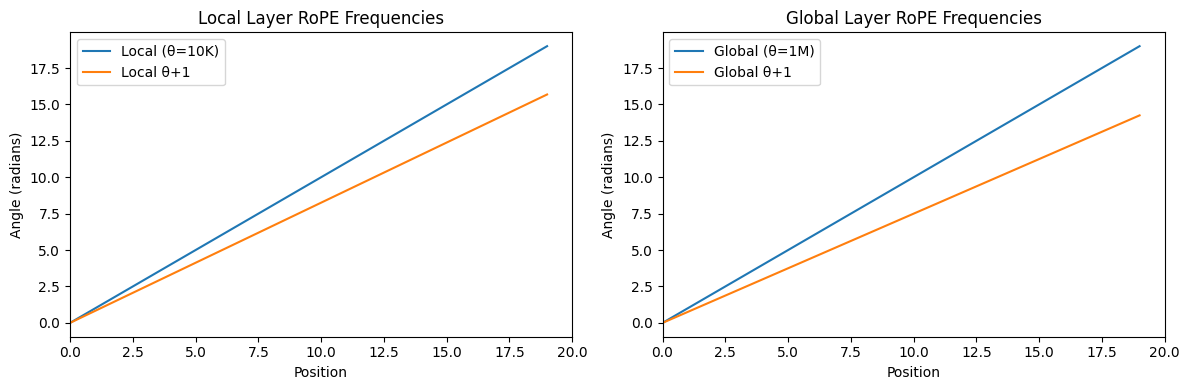

In [2]:
def compute_rope_freqs_rope(head_dim, seq_len, theta_base=10_000.0):
    """Compute RoPE frequencies for a given layer type."""
    # Compute inverse frequencies: 1/theta^(i/d_k)
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2).float() / head_dim))
    # Compute angles for each position
    t = torch.arange(seq_len)
    freqs = torch.outer(t, inv_freq)  # (seq_len, head_dim/2)
    return freqs


# Local layer RoPE (theta=10K)
freqs_local = compute_rope_freqs_rope(head_dim, seq_len, rope_theta_local)

# Global layer RoPE (theta=1M) - higher theta = slower rotation = longer-range awareness
freqs_global = compute_rope_freqs_rope(head_dim, seq_len, rope_theta_global)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(freqs_local[:20, 0].detach().numpy(), label="Local (θ=10K)")
plt.plot(freqs_local[:20, 1].detach().numpy(), label="Local θ+1")
plt.title("Local Layer RoPE Frequencies")
plt.xlabel("Position")
plt.ylabel("Angle (radians)")
plt.legend()
plt.xlim(0, 20)

plt.subplot(1, 2, 2)
plt.plot(freqs_global[:20, 0].detach().numpy(), label="Global (θ=1M)")
plt.plot(freqs_global[:20, 1].detach().numpy(), label="Global θ+1")
plt.title("Global Layer RoPE Frequencies")
plt.xlabel("Position")
plt.ylabel("Angle (radians)")
plt.legend()
plt.xlim(0, 20)

plt.tight_layout()
plt.show()

**The Axes**
* X-axis (Position): This represents the position of the token in the sequence (e.g., the 1st word, the 5th word, the 15th word).
* Y-axis (Angle in radians): This is the total accumulated rotation angle ($\phi$) applied to the vector at that specific position. A value of $2\pi$ ($\approx 6.28$) means the vector has completed one full rotation around the circle.


**The Lines**

Both graphs plot the rotation angle for the first two dimension pairs:
* Blue Line: The rotation angle for the very first dimension pair ($i=0$).
* Orange Line: The rotation angle for the second dimension pair ($i=1$).

**Local Layer (Left Graph)**

* Base Frequency ($\theta = 10,000$): This graph represents the fast-rotating local layers used for Sliding Window Attention.
* Observation: Look at the blue line. By position 19, the vector has rotated roughly 19 radians. Since one full circle is $\approx 6.28$ radians, this vector has spun around the circle exactly 3 times in just 19 words!
* Why? This rapid rotation provides extremely high-resolution, high-precision positional tracking for local grammar and syntax.


**Global Layer (Right Graph)**

* Base Frequency ($\theta = 1,000,000 \times 8$): This graph represents the slow-rotating global layers, which use a massive base frequency and an 8x context extension scaling factor to handle 128,000 tokens.
* Observation: While the blue line ($i=0$) looks identical (because $i=0$ is unaffected by the base $\theta$ in the standard formula, as $\theta^{-0} = 1$), look closely at the Orange Line ($i=1$).
* The Difference: In the local layer, the orange line reaches an angle of $\approx 15.5$ radians by position 19. In the global layer, the orange line only reaches $\approx 14$ radians by position 19.
* Why? The massive base $\theta$ of $8,000,000$ causes the rotation speed to drop off significantly faster across the dimensions. This prevents the vectors from spinning too fast over long distances, acting as a macroscopic "map" that prevents the model from losing its place in a 128K context window.

## 2. Gemma 3's Dual-Frequency RoPE: Rescaled Global Layers

In Gemma 3, global layers use theta=1M (vs 10K for local). Combined with the rescale factor of 8, this enables the model to handle **128K context**.

$$\theta_{global} = 10^6 \times \text{rescale\_factor} = 8 \times 10^6$$

In [3]:
def compute_rope_with_frequency(head_dim, seq_len, theta_base, rescale_factor=1.0):
    """Compute cos and sin for RoPE with linear context scaling."""
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2).float() / head_dim))
    
    t = torch.arange(seq_len) * rescale_factor 
    freqs = torch.outer(t, inv_freq)
    
    return torch.cos(freqs), torch.sin(freqs)

# For a given layer, choose the right RoPE frequency and scale
def get_layer_rope_freq_and_scale(layer_idx):
    """Return theta and rescale factor for the given layer."""
    if layer_idx % 6 == 5:  # Global layer uses 1M theta and 8x extension
        return rope_theta_global, rope_rescale_factor
    
    # Local SWA layers use 10K theta and standard 1x scale
    return rope_theta_local, 1.0

## 🔄 Applying RoPE: Vector Rotations in 2D Pairs

RoPE works by grouping the $d$-dimensional head vector into $d/2$ pairs of two dimensions and rotating each pair independently.

### 🧮 2D Rotation Formula:
For a pair of coordinates $(x_1, x_2)$ representing dimensions $i$ and $i + d/2$ of a vector, and a rotation angle $\phi = t \cdot \omega_i$:
$$\begin{pmatrix} x'_1 \\ x'_2 \end{pmatrix} = \begin{pmatrix} \cos\phi & -\sin\phi \\ \sin\phi & \cos\phi \end{pmatrix} \begin{pmatrix} x_1 \\ x_2 \end{pmatrix}$$
This expands algebraically to:
$$x'_1 = x_1 \cos\phi - x_2 \sin\phi$$
$$x'_2 = x_1 \sin\phi + x_2 \cos\phi$$

### 🛠️ Vectorized PyTorch Implementation:
We slice the head vector into left and right halves of size $d/2$:
- `x_left` contains the first half of the dimensions.
- `x_right` contains the second half.
We rotate them together and concatenate the results back into a single tensor, ensuring rapid vectorized execution on GPU hardware!

In [4]:
def apply_rope(x, cos, sin):
    """Apply rotary positional embedding.

    Args:
        x:   (B, H, T, D) — query or key tensor
        cos: (1, 1, T, D//2) — cosine frequencies
        sin: (1, 1, T, D//2) — sine frequencies
    """
    d = x.shape[-1]
    x_left = x[..., : d // 2]  # first half of head_dim
    x_right = x[..., d // 2 :]  # second half of head_dim

    # Rotation formula applied per 2D pair (x_left[i], x_right[i]):
    #   x'_left  = x_left  * cos - x_right * sin
    #   x'_right = x_left  * sin + x_right * cos
    rotated_left = x_left * cos - x_right * sin
    rotated_right = x_left * sin + x_right * cos

    return torch.cat([rotated_left, rotated_right], dim=-1)


# Verify with dummy data
x = torch.randn(1, 1, 4, 96)  # (B, H, T, D)
cos, sin = compute_rope_with_frequency(96, 4, 10_000)
# cos/sin shape: (T, D//2) — unsqueeze for broadcast over B and H
cos = cos[: x.shape[-2]].unsqueeze(0).unsqueeze(0)  # (1, 1, T, D//2)
sin = sin[: x.shape[-2]].unsqueeze(0).unsqueeze(0)

x_rotated = apply_rope(x, cos, sin)
print(f"Input shape:   {x.shape}")
print(f"Rotated shape: {x_rotated.shape}")
assert x_rotated.shape == x.shape
print("✅ RoPE applied successfully!")

Input shape:   torch.Size([1, 1, 4, 96])
Rotated shape: torch.Size([1, 1, 4, 96])
✅ RoPE applied successfully!


## 4. Why is this good?

When we compute the dot product between a Query at position $m$ and a Key at position $n$, the rotation ensures the score depends only on the **relative distance** $(m - n)$, not absolute positions. This is the key insight of RoPE.

Gemma 3's dual-frequency design:
- **Local (θ=10K)**: standard rotation for short-range attention
- **Global (θ=8M)**: much slower rotation → finer-grained distance encoding over long sequences

## 📉 Visualizing Positional Decay: The Relational Power of RoPE

One of the main reasons RoPE outperforms absolute positional embeddings (like sinusoidal lookups) is its **relative decay property**. 

### 🧮 Why Relative Distance Decays:
The dot product between Query $q_m$ (at position $m$) and Key $k_n$ (at position $n$) after RoPE rotation depends strictly on the **relative distance** $(m - n)$:
$$\langle \text{RoPE}(q, m), \text{RoPE}(k, n) \rangle = q^T \mathbf{R}_{n-m} k$$
Where $\mathbf{R}_{n-m}$ is the relative rotation matrix. As the distance $|m - n|$ increases, the average dot product naturally decays toward zero. This matches our intuition that nearby words are more relevant to each other than words far apart, providing a strong inductive bias!

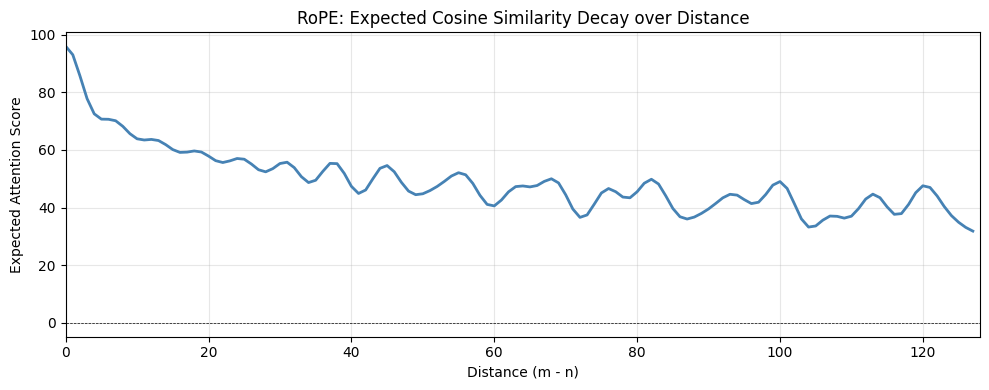

In [5]:
# To see the true mathematical decay, we need to average over many vectors.
# A single random vector just gives a noisy wave!
batch_size = 100_000
head_dim = 96
max_distance = 128

# 1. We use the SAME base vector to simulate tokens that are perfectly aligned semantically.
# We want to see how POSITIONAL distance alone penalizes their attention score.
v = torch.randn(batch_size, 1, 1, head_dim)

distances = range(max_distance)
dot_products = []

cos_local, sin_local = compute_rope_with_frequency(head_dim, max_distance, 10_000)

# 2. Rotate the vector at position 0 (our anchor token)
c0 = cos_local[0:1].unsqueeze(0).unsqueeze(0)
s0 = sin_local[0:1].unsqueeze(0).unsqueeze(0)
x1 = apply_rope(v, c0, s0)

for d in distances:
    # 3. Rotate the SAME base vector at position d
    cd = cos_local[d : d + 1].unsqueeze(0).unsqueeze(0)
    sd = sin_local[d : d + 1].unsqueeze(0).unsqueeze(0)
    
    x2 = apply_rope(v, cd, sd)
    
    # 4. Calculate the dot product across the head dimension, then average over the batch of 10,000
    dot = (x1 * x2).sum(dim=-1).mean().item()
    dot_products.append(dot)

# 5. Plot the theoretical decay
plt.figure(figsize=(10, 4))
plt.plot(list(distances), dot_products, color='steelblue', linewidth=2)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.xlabel("Distance (m - n)")
plt.ylabel("Expected Attention Score")
plt.title("RoPE: Expected Cosine Similarity Decay over Distance")
plt.grid(True, alpha=0.3)
plt.xlim(0, max_distance)
plt.tight_layout()
plt.show()

## Key Takeaway

Gemma 3 uses **dual-frequency RoPE**:
- Local layers: θ=10K (same as Gemma 2)
- Global layers: θ=8M (10K × rescale_factor=8 × 10, extended for 128K context)
- Each pair of dimensions is rotated by a different frequency